In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!pip install -q vllm

In [1]:
import re, string, json, time, numpy as np
from datasets import load_dataset
from vllm import LLM, SamplingParams

TAG = "qwen7b"
llm = LLM("Qwen/Qwen2.5-7B-Instruct-AWQ", quantization="awq", dtype="float16",
          gpu_memory_utilization=0.90, max_model_len=2048, enforce_eager=True)
tok = llm.get_tokenizer()

def make_prompt(q):
    msgs = [{"role":"system","content":"Answer with a short phrase only, no explanation."},
            {"role":"user","content":q}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

def norm(s):
    s = s.lower()
    s = "".join(c for c in s if c not in string.punctuation)
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    return " ".join(s.split())

def is_correct(pred, aliases):
    p = " " + norm(pred) + " "
    return any(na and (" " + na + " ") in p for na in map(norm, aliases))

N = 5000
ds = load_dataset("mandarjoshi/trivia_qa", "rc.nocontext", split="validation").select(range(N))
prompts = [make_prompt(x["question"]) for x in ds]
t0 = time.time()
g_out = llm.generate(prompts, SamplingParams(temperature=0, max_tokens=32, logprobs=0))
s_out = llm.generate(prompts, SamplingParams(temperature=1.0, n=10, max_tokens=32))
print("generation time:", round(time.time()-t0), "s")

records = []
for x, g, s in zip(ds, g_out, s_out):
    al = x["answer"]["aliases"]; go = g.outputs[0]
    lps = [list(d.values())[0].logprob for d in go.logprobs]
    records.append({"question": x["question"], "aliases": al, "greedy": go.text.strip(),
        "greedy_correct": bool(is_correct(go.text.strip(), al)),
        "greedy_logprob_sum": sum(lps), "greedy_logprob_mean": sum(lps)/max(len(lps),1),
        "samples": [o.text.strip() for o in s.outputs],
        "samples_correct": [bool(is_correct(o.text.strip(), al)) for o in s.outputs]})
json.dump(records, open(f"/kaggle/working/triviaqa_{TAG}.json", "w"))
print("greedy accuracy:", np.mean([r["greedy_correct"] for r in records]))

INFO 10-03 17:54:12 [api_utils.py:286] non-default args: {'dtype': 'float16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'quantization': 'awq', 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-7B-Instruct-AWQ'}


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

INFO 10-03 17:54:28 [model.py:692] Resolved architecture: Qwen2ForCausalLM
INFO 10-03 17:54:28 [model.py:2030] Using max model len 2048
INFO 10-03 17:54:29 [scheduler.py:288] Chunked prefill is enabled with max_num_batched_tokens=8192.


model.safetensors.index.json:   0%|          | 0.00/62.7k [00:00<?, ?B/s]

Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

...

(EngineCore pid=317) WARNING 10-03 17:55:57 [jit_monitor.py:141] Triton kernel JIT compilation during inference: kernel_unified_attention. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=317) WARNING 10-03 17:55:57 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topk_log_softmax_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts: 100%|██████████| 5000/5000 [01:38<00:00, 50.71it/s, est. speed input: 2146.54 toks/s, output: 207.29 toks/s] 


Rendering prompts:   0%|          | 0/5000 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 50000/50000 [08:09<00:00, 102.09it/s, est. speed input: 4321.25 toks/s, output: 440.45 toks/s] 


generation time: 599 s
greedy accuracy: 0.52


In [2]:
import itertools, torch
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

recs = json.load(open(f"/kaggle/working/triviaqa_{TAG}.json"))
dev = "cuda:1"
nli_tok = AutoTokenizer.from_pretrained("microsoft/deberta-large-mnli")
nli = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-large-mnli").to(dev).half().eval()
ENT = [i for i, l in nli.config.id2label.items() if l.lower().startswith("entail")][0]

@torch.no_grad()
def entails(pairs, bs=64):
    out = []
    for i in range(0, len(pairs), bs):
        b = pairs[i:i+bs]
        enc = nli_tok([p for p, h in b], [h for p, h in b], return_tensors="pt",
                      padding=True, truncation=True, max_length=128).to(dev)
        out += (nli(**enc).logits.argmax(-1) == ENT).tolist()
    return out

def semantic_entropy(question, samples):
    uniq = list(dict.fromkeys(norm(s) for s in samples if norm(s)))
    if len(uniq) <= 1: return 0.0
    pairs, idx = [], []
    for i, j in itertools.combinations(range(len(uniq)), 2):
        a, b = f"{question} {uniq[i]}", f"{question} {uniq[j]}"
        pairs += [(a, b), (b, a)]; idx.append((i, j))
    res = entails(pairs)
    parent = list(range(len(uniq)))
    def find(x):
        while parent[x] != x: x = parent[x]
        return x
    for k, (i, j) in enumerate(idx):
        if res[2*k] and res[2*k+1]: parent[find(i)] = find(j)
    cl = {u: find(i) for i, u in enumerate(uniq)}
    c = Counter(cl[norm(s)] for s in samples if norm(s))
    p = np.array(list(c.values()), float); p /= p.sum()
    return float(-(p * np.log(p)).sum())

for n, r in enumerate(recs):
    g = norm(r["greedy"])
    r["selfcons"] = float(np.mean([norm(s) == g for s in r["samples"]]))
    r["sem_ent"] = semantic_entropy(r["question"], r["samples"])
    if n % 500 == 0: print(n, flush=True)
json.dump(recs, open(f"/kaggle/working/triviaqa_{TAG}_scored.json", "w"))

def ece(conf, y, bins=10):
    conf, y = np.asarray(conf), np.asarray(y, float)
    edges = np.linspace(0, 1, bins + 1); e = 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any(): e += m.mean() * abs(y[m].mean() - conf[m].mean())
    return e

rng = np.random.default_rng(0)
def boot_ci(s, y, B=1000):
    a = [roc_auc_score(y[i], s[i]) for i in (rng.integers(0, len(y), len(y)) for _ in range(B))]
    return np.percentile(a, [2.5, 97.5])
def paired_ci(s1, s2, y, B=1000):
    d = []
    for _ in range(B):
        i = rng.integers(0, len(y), len(y))
        d.append(roc_auc_score(y[i], s1[i]) - roc_auc_score(y[i], s2[i]))
    return np.percentile(d, [2.5, 97.5])

y = np.array([r["greedy_correct"] for r in recs])
X = np.column_stack([[r["greedy_logprob_sum"] for r in recs], [r["greedy_logprob_mean"] for r in recs],
                     [r["selfcons"] for r in recs], [r["sem_ent"] for r in recs]])
tp = np.exp(X[:, 0]); se = -X[:, 3]
names = ["token_prob", "logprob_mean", "selfcons", "semantic_ent(neg)"]
sc = [tp, X[:, 1], X[:, 2], se]
print(f"{'method':20s} AUROC  95% CI")
for n_, s in zip(names, sc):
    lo, hi = boot_ci(s, y); print(f"{n_:20s} {roc_auc_score(y, s):.3f}  [{lo:.3f}, {hi:.3f}]")
p = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression()), X, y, cv=5, method="predict_proba")[:, 1]
lo, hi = boot_ci(p, y)
print(f"{'combined (5-fold)':20s} {roc_auc_score(y, p):.3f}  [{lo:.3f}, {hi:.3f}]  ECE {ece(p, y):.3f}  Brier {brier_score_loss(y, p):.3f}")
print("combined - token_prob paired CI:", paired_ci(p, tp, y).round(4))
print("semantic - token_prob paired CI:", paired_ci(se, tp, y).round(4))

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.62GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0
500
1000
1500
2000
2500
3000
3500
4000
4500
method               AUROC  95% CI
token_prob           0.849  [0.839, 0.859]
logprob_mean         0.844  [0.833, 0.854]
selfcons             0.840  [0.830, 0.851]
semantic_ent(neg)    0.828  [0.817, 0.840]
combined (5-fold)    0.850  [0.840, 0.860]  ECE 0.043  Brier 0.158
combined - token_prob paired CI: [-0.0023  0.0055]
semantic - token_prob paired CI: [-0.0276 -0.0135]


In [3]:
from datasets import load_dataset
mm = load_dataset("cais/mmlu", "all", split="test")
letters = ["A", "B", "C", "D"]
let_ids = [tok.encode(l, add_special_tokens=False)[0] for l in letters]

def mmlu_prompt(x):
    opts = "\n".join(f"{l}. {c}" for l, c in zip(letters, x["choices"]))
    msgs = [{"role": "system", "content": "Answer with the letter of the correct option only."},
            {"role": "user", "content": f"{x['question']}\n{opts}\nAnswer:"}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

outs = llm.generate([mmlu_prompt(x) for x in mm],
                    SamplingParams(temperature=0, max_tokens=1, logprobs=20))
P = np.full((len(mm), 4), -1e9)
for i, o in enumerate(outs):
    lp = o.outputs[0].logprobs[0]
    for k, t in enumerate(let_ids):
        if t in lp: P[i, k] = lp[t].logprob
print("all 4 letters found:", (P > -1e8).all(1).mean())
Z = np.exp(P - P.max(1, keepdims=True)); probs = Z / Z.sum(1, keepdims=True)
labels = np.array(mm["answer"]); subjects = np.array(mm["subject"])
print("MMLU accuracy:", (probs.argmax(1) == labels).mean())
np.savez(f"/kaggle/working/mmlu_{TAG}.npz", probs=probs, labels=labels, subjects=subjects)

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

all/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.50MB            

all/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

all/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  408kB            

...

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating auxiliary_train split:   0%|          | 0/99842 [00:00<?, ? examples/s]

Rendering prompts:   0%|          | 0/14042 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 14042/14042 [16:54<00:00, 13.84it/s, est. speed input: 1792.71 toks/s, output: 13.84 toks/s]


all 4 letters found: 0.9778521578122774
MMLU accuracy: 0.6991169349095571


In [4]:
def qhat_lac(pr, y, alpha):
    s = np.sort(1 - pr[np.arange(len(y)), y]); n = len(s)
    return s[min(int(np.ceil((n + 1) * (1 - alpha))), n) - 1]

def evaluate(q, pr, y):
    sets = (1 - pr) <= q
    return sets[np.arange(len(y)), y].mean(), sets.sum(1).mean()

rng = np.random.default_rng(0); alpha = 0.1
uniq = np.unique(subjects)

# iid baseline
iid = []
for _ in range(100):
    perm = rng.permutation(len(labels)); h = len(perm) // 2
    iid.append(evaluate(qhat_lac(probs[perm[:h]], labels[perm[:h]], alpha), probs[perm[h:]], labels[perm[h:]]))
r = np.array(iid)
print(f"iid: coverage {r[:,0].mean():.3f} (std {r[:,0].std():.3f}) | set size {r[:,1].mean():.2f}")

# harsh shift: calibrate on easy subjects, test on hard
acc_s = {s: (probs[subjects == s].argmax(1) == labels[subjects == s]).mean() for s in uniq}
order = sorted(uniq, key=lambda s: -acc_s[s])
me = np.isin(subjects, order[:len(order)//2]); mh = ~me
q = qhat_lac(probs[me], labels[me], alpha)
c, s = evaluate(q, probs[mh], labels[mh])
print(f"easy->hard (no fix): coverage {c:.3f} | set size {s:.2f}")

# Fix A: recalibrate with k target labels
idx_h = np.where(mh)[0]
for k in [50, 100, 200, 500, 1000]:
    cov, sz = [], []
    for _ in range(200):
        p = rng.permutation(idx_h); ci, ti = p[:k], p[k:]
        a, b = evaluate(qhat_lac(probs[ci], labels[ci], alpha), probs[ti], labels[ti])
        cov.append(a); sz.append(b)
    print(f"recalibrate k={k:4d}: coverage {np.mean(cov):.3f} (std {np.std(cov):.3f}) | set size {np.mean(sz):.2f}")

# Fix B: per-subject thresholds vs global
g_w, s_w, g_b, s_b = [], [], [], []
for _ in range(30):
    cm = np.zeros(len(labels), bool)
    for s_ in uniq:
        i = rng.permutation(np.where(subjects == s_)[0]); cm[i[:len(i)//2]] = True
    qg = qhat_lac(probs[cm], labels[cm], alpha); gc, sc = [], []
    for s_ in uniq:
        i = np.where(subjects == s_)[0]; ic, it = i[cm[i]], i[~cm[i]]
        gc.append(evaluate(qg, probs[it], labels[it])[0])
        sc.append(evaluate(qhat_lac(probs[ic], labels[ic], alpha), probs[it], labels[it])[0])
    g_w.append(min(gc)); s_w.append(min(sc))
    g_b.append(np.mean(np.array(gc) < 0.85)); s_b.append(np.mean(np.array(sc) < 0.85))
print(f"global thr:      worst-subject cov {np.mean(g_w):.3f} | frac <0.85: {np.mean(g_b):.2f}")
print(f"per-subject thr: worst-subject cov {np.mean(s_w):.3f} | frac <0.85: {np.mean(s_b):.2f}")

iid: coverage 0.900 (std 0.005) | set size 1.82
easy->hard (no fix): coverage 0.753 | set size 1.53
recalibrate k=  50: coverage 0.899 (std 0.039) | set size 2.36
recalibrate k= 100: coverage 0.896 (std 0.030) | set size 2.31
recalibrate k= 200: coverage 0.900 (std 0.020) | set size 2.33
recalibrate k= 500: coverage 0.901 (std 0.013) | set size 2.33
recalibrate k=1000: coverage 0.899 (std 0.011) | set size 2.32
global thr:      worst-subject cov 0.699 | frac <0.85: 0.10
per-subject thr: worst-subject cov 0.773 | frac <0.85: 0.12


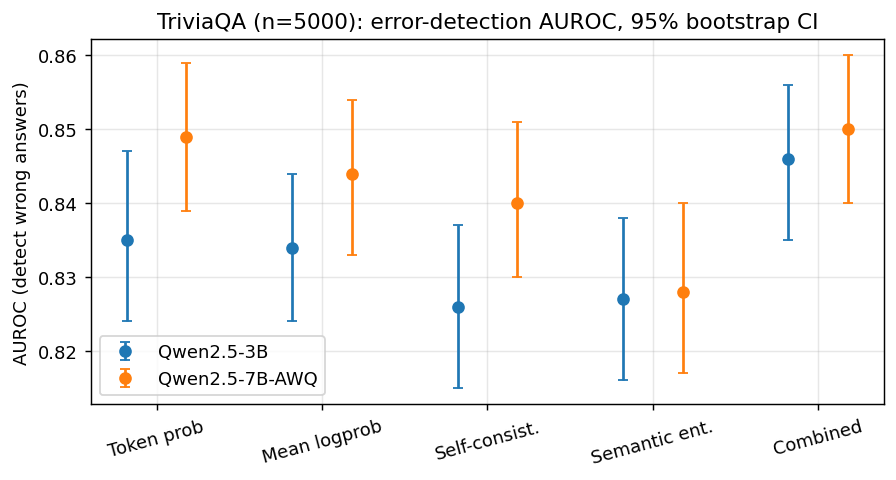

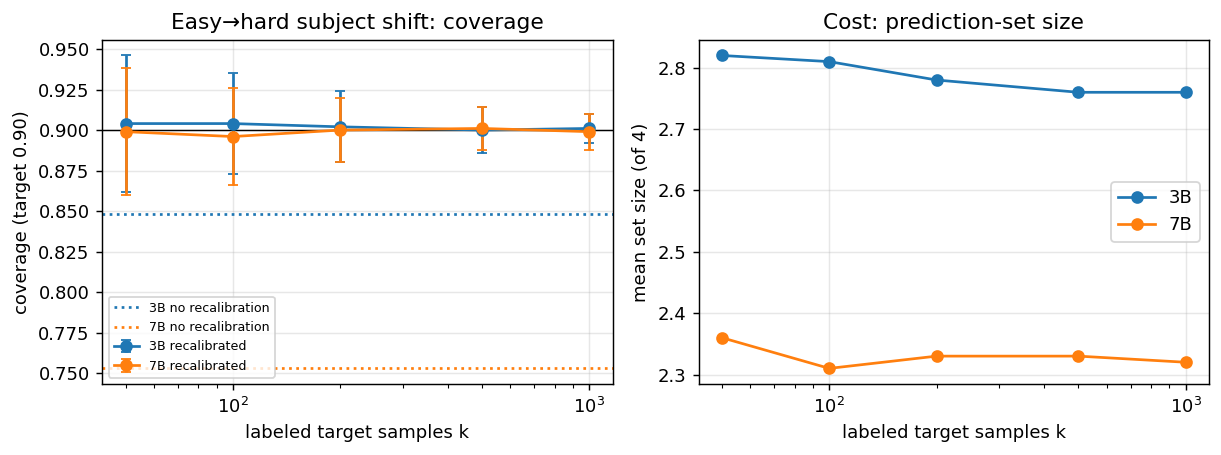

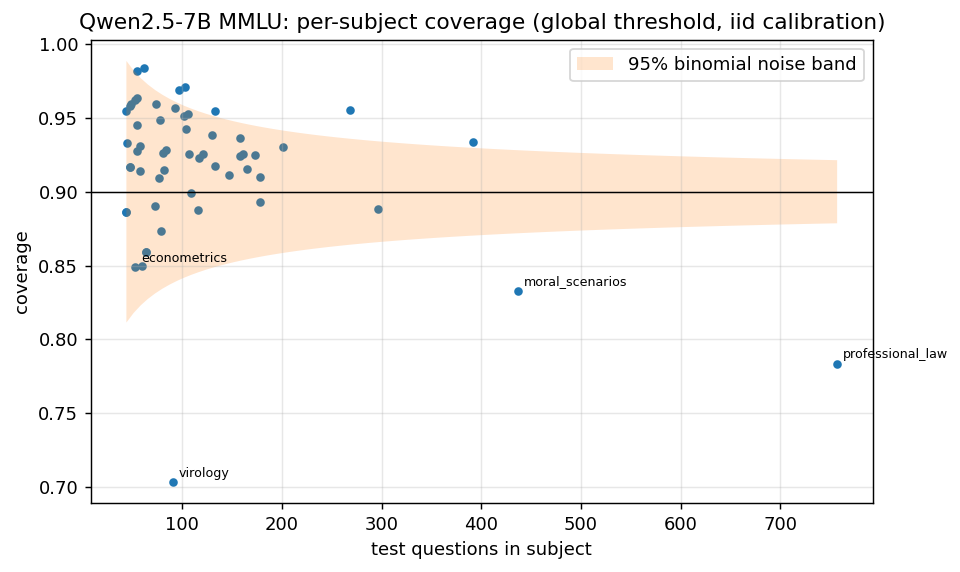

fraction of subjects outside noise band: 0.175


In [5]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10, "figure.dpi": 130})

# ---------- Fig 1: AUROC with 95% CIs ----------
methods = ["Token prob", "Mean logprob", "Self-consist.", "Semantic ent.", "Combined"]
a3 = [0.835, 0.834, 0.826, 0.827, 0.846]; ci3 = [(0.824,0.847),(0.824,0.844),(0.815,0.837),(0.816,0.838),(0.835,0.856)]
a7 = [0.849, 0.844, 0.840, 0.828, 0.850]; ci7 = [(0.839,0.859),(0.833,0.854),(0.830,0.851),(0.817,0.840),(0.840,0.860)]
x = np.arange(len(methods)); w = 0.36
fig, ax = plt.subplots(figsize=(7, 3.8))
for off, a, ci, lab in [(-w/2, a3, ci3, "Qwen2.5-3B"), (w/2, a7, ci7, "Qwen2.5-7B-AWQ")]:
    err = [[v - c[0] for v, c in zip(a, ci)], [c[1] - v for v, c in zip(a, ci)]]
    ax.errorbar(x + off, a, yerr=err, fmt="o", capsize=3, label=lab)
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel("AUROC (detect wrong answers)"); ax.set_title("TriviaQA (n=5000): error-detection AUROC, 95% bootstrap CI")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig("/kaggle/working/fig1_auroc.png"); plt.show()

# ---------- Fig 2: coverage vs number of target labels ----------
ks = [50, 100, 200, 500, 1000]
cov3 = [0.904, 0.904, 0.902, 0.900, 0.901]; sd3 = [0.042, 0.031, 0.022, 0.014, 0.009]; sz3 = [2.82, 2.81, 2.78, 2.76, 2.76]
cov7 = [0.899, 0.896, 0.900, 0.901, 0.899]; sd7 = [0.039, 0.030, 0.020, 0.013, 0.011]; sz7 = [2.36, 2.31, 2.33, 2.33, 2.32]
fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.6))
for cov, sd, lab, nofix in [(cov3, sd3, "3B", 0.848), (cov7, sd7, "7B", 0.753)]:
    l = axs[0].errorbar(ks, cov, yerr=sd, marker="o", capsize=3, label=f"{lab} recalibrated")
    axs[0].axhline(nofix, ls=":", color=l[0].get_color(), label=f"{lab} no recalibration")
axs[0].axhline(0.90, color="k", lw=0.8); axs[0].set_xscale("log"); axs[0].set_xlabel("labeled target samples k")
axs[0].set_ylabel("coverage (target 0.90)"); axs[0].set_title("Easy→hard subject shift: coverage"); axs[0].legend(fontsize=7); axs[0].grid(alpha=0.3)
axs[1].plot(ks, sz3, "o-", label="3B"); axs[1].plot(ks, sz7, "o-", label="7B")
axs[1].set_xscale("log"); axs[1].set_xlabel("labeled target samples k"); axs[1].set_ylabel("mean set size (of 4)")
axs[1].set_title("Cost: prediction-set size"); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/fig2_coverage_vs_k.png"); plt.show()

# ---------- Fig 3: per-subject coverage under iid calibration (7B) ----------
rng = np.random.default_rng(1)
perm = rng.permutation(len(labels)); h = len(perm) // 2
cal, te = perm[:h], perm[h:]
q = qhat_lac(probs[cal], labels[cal], 0.1)
rows = []
for s in np.unique(subjects):
    i = te[subjects[te] == s]
    if len(i) >= 20: rows.append((evaluate(q, probs[i], labels[i])[0], s, len(i)))
rows.sort()
covs = np.array([r[0] for r in rows]); ns = np.array([r[2] for r in rows])
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(ns, covs, s=14)
nn = np.linspace(ns.min(), ns.max(), 100)
ax.fill_between(nn, 0.9 - 1.96*np.sqrt(0.09/nn), 0.9 + 1.96*np.sqrt(0.09/nn), alpha=0.2, label="95% binomial noise band")
ax.axhline(0.90, color="k", lw=0.8)
for c, s, n in rows[:4]: ax.annotate(s, (n, c), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("test questions in subject"); ax.set_ylabel("coverage"); ax.legend()
ax.set_title("Qwen2.5-7B MMLU: per-subject coverage (global threshold, iid calibration)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig("/kaggle/working/fig3_per_subject.png"); plt.show()
print("fraction of subjects outside noise band:",
      np.mean(np.abs(covs - 0.9) > 1.96*np.sqrt(0.09/ns)).round(3))